In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import glob
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None
# https://stackoverflow.com/questions/20625582/how-to-deal-with-settingwithcopywarning-in-pandas
from pathlib import Path
from tqdm import tqdm
import re

%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
# Samples vs Power (fixed dataset)
def samples_vs_power(df: pd.DataFrame, **filter):
    # apply filter
    if len(df) <= 0:
        print('Warning: dataframe is empty.')
        return list()
    assert 'dataset' in filter, 'Error: expected key <dataset> to be a filter.'
    idx = df.index > -1
    for col, value in filter.items():
        if isinstance(value, str) and value[0]=='[' and value[-1]==']':
            idx = idx & df.get(col, None).str.contains(value[1:-1])
        else:
            idx = idx & (df.get(col, None)==value)
    df: pd.DataFrame = df[idx]
    if len(df) == 0: return list()
    df['size'] = df['dataset'].str.split('-', expand=True)[1].astype(int)

    stats = list()
    for size in df['size'].unique():
        avg_power = df[df['size'] == size]['power'].mean()
        std = df[df['size'] == size]['power'].std()
        if size <= 4000:
            stats.append((size, avg_power, std))
    return sorted(stats, key=lambda x: x[0])    # return sorted by size

In [3]:
def collate_samples(stats: list):                       # [(x1,y1,std1), (x2,y2,std2), ...]
    x, y, std = (np.array(obj) for obj in zip(*stats))  # (x1,x2,...), (y1,y2,...), (std1,std2,...)
    return {
        'x,y': (x, y),
        'std': (x, np.clip(y-std,0,1), np.clip(y+std,0,1)),
    }
    return x, y, y-std, y+std

(-0.05500000000000001,
 0.05500000000000001,
 -0.05500000000000001,
 0.05500000000000001)

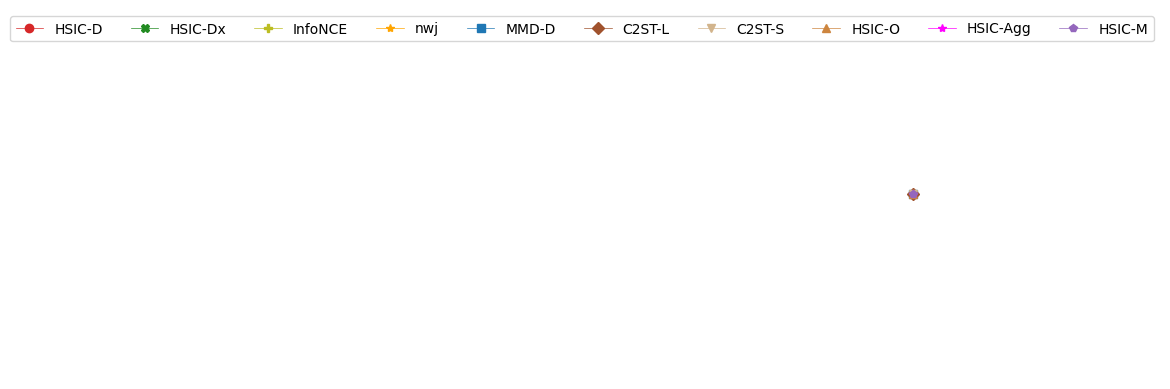

In [4]:
# LOAD DATAFRAME
EXPDIR = '../src/exp/eval/sinusoid/'
RUNS = ('final-datasize', 'cedar-1', 'cedar-2', 'cedar-3')

df = dict()
for method in ['hsic', 'c2st', 'mmd', 'infonce', 'nwj']:
    runs = []
    for file in glob.glob(f'{EXPDIR}/*/stats-{method}.csv'):
        if Path(file).parent.name in RUNS:
            runs.append(pd.read_csv(file))
    df[method] = pd.concat(runs, axis=0) if runs else pd.DataFrame()

# DEFINE LEGEND
legend = dict()
legend['hsic-d'] = {'label': 'HSIC-D', 'marker': 'o-', 'color': 'tab:red'}
legend['hsic-dx'] = {'label': 'HSIC-Dx', 'marker': 'X-', 'color': 'forestgreen'}
legend['hsic-o'] = {'label': 'HSIC-O', 'marker': '^-', 'color': 'peru'}
legend['hsic-agg'] = {'label': 'HSIC-Agg', 'marker': '*-', 'color': 'magenta'}
legend['hsic-m'] = {'label': 'HSIC-M', 'marker': 'p-', 'color': 'tab:purple'}
legend['c2st-l'] = {'label': 'C2ST-L', 'marker': 'D-', 'color': 'sienna'}
legend['c2st-s'] = {'label': 'C2ST-S', 'marker': 'v-', 'color': 'tan'}
legend['mmd-d'] = {'label': 'MMD-D', 'marker': 's-', 'color': 'tab:blue'}
legend['infonce'] = {'label': 'InfoNCE', 'marker': 'P-', 'color': 'tab:olive'}
legend['nwj'] = {'label': 'nwj', 'marker': '*-', 'color': 'orange'}
# ordered from least to most important
methods = ['hsic-m', 'hsic-agg', 'hsic-o', 'c2st-s', 'c2st-l', 'mmd-d', 'nwj', 'infonce', 'hsic-dx', 'hsic-d']

# Plot legend
for method in reversed(methods):
    plt.plot(0, 0, legend[method]['marker'], linewidth=0.5, color=legend[method]['color'])
plt.legend([legend[method]['label'] for method in reversed(methods)], ncol=len(methods))
plt.axis(False)
# plt.savefig(f"toyplots/legend.pdf", format="pdf", bbox_inches="tight")

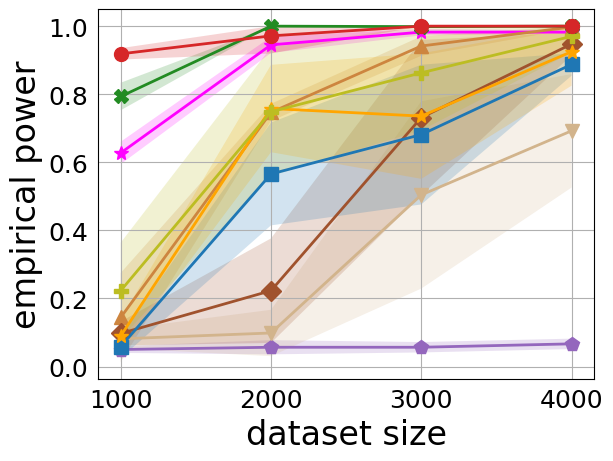

In [5]:
# power vs samples
DATASET = f"[Sinusoid-]"
LINEWIDTH = 2
MARKERSIZE = 10

stats = dict()
stats['hsic-d'] = samples_vs_power(df['hsic'], dataset=DATASET, method='hsic', model='mlp1x8x12x8-squared')
stats['hsic-dx'] = samples_vs_power(df['hsic'], dataset=DATASET, method='hsic', model='[tied]')
stats['hsic-agg'] = samples_vs_power(df['hsic'], dataset=DATASET, method='hsic', model='agg')
stats['hsic-o'] = samples_vs_power(df['hsic'], dataset=DATASET, method='hsic', model='bandwidth-squared')
stats['hsic-m'] = samples_vs_power(df['hsic'], dataset=DATASET, method='hsic', model='median')
stats['mmd-d'] = samples_vs_power(df['mmd'], dataset=DATASET, method='mmd', model='id-id@mlp2x8x12x8')
stats['c2st-l'] = samples_vs_power(df['c2st'], dataset=DATASET, method='c2st-l', model='id-id@mlp2x8x12x8x1')
stats['c2st-s'] = samples_vs_power(df['c2st'], dataset=DATASET, method='c2st-s', model='id-id@mlp2x8x12x8x1')
stats['infonce'] = samples_vs_power(df['infonce'], dataset=DATASET, method='infonce', model='id-id@mlp2x8x12x8x1')
stats['nwj'] = samples_vs_power(df['nwj'], dataset=DATASET, method='nwj', model='id-id@mlp2x8x12x8x1')

for method in methods:
    try:
        plt.plot(*collate_samples(stats[method])['x,y'],
                legend[method]['marker'],
                linewidth = LINEWIDTH,
                markersize = MARKERSIZE,
                color = legend[method]['color'],)
        plt.fill_between(*collate_samples(stats[method])['std'],
                        facecolor = legend[method]['color'],
                        alpha = 0.2)
    except ValueError:
        print(f"Warning: no data found for method {method}.")


# plt.legend(['HSIC-D', 'HSIC-Dx', 'HSIC-Agg', 'HSIC-O', 'HSIC-M', 'MMD-D', 'C2ST-L', 'C2ST-S'], ncol=8)
plt.grid()
#plt.title(DATASET)
plt.xlabel("dataset size", fontsize=24)
plt.ylabel("empirical power", fontsize=24)
# plt.xlim(xmin=90)
plt.ylim(top=1.05)

plt.rcParams['axes.linewidth'] = 0.2
plt.tick_params(left=False, labelsize=18)
plt.tick_params(bottom=False, labelsize=18)
# plt.gca().xaxis.set_major_locator(plt.MultipleLocator(1000))
# plt.savefig(f"plots/sinusoid/power_vs_datasize_{DATASET.replace('-','')[1:-1]}.pdf", format="pdf", bbox_inches="tight")